### Classify Articles into Field

The plan is to use abstracts and keywords provided for each paper and to classify them using a transformers model.
The output should be one field category per paper, not multiple.






In [ ]:
# Install dependencies (run once)
# !pip install sentence-transformers scikit-learn pandas numpy matplotlib seaborn umap-learn os pyreadr

In [2]:
import pandas as pd
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')
import pyreadr

# Reproducibility
RANDOM_STATE = 42
N_CLUSTERS = 10 # change this to change into how many fields articles are classified

# Set Working Directory
os.chdir(r"D:\Projektfolder1 (Miethe, Grosenick)\zz_AmelieMisc\thankyou")



---
## STEP 1: Load and prepare Data 

In [16]:
# Load R file from data/gen subfolder
result = pyreadr.read_r(r'data\gen\dt_paper_level.RData')

# Check what objects are in the file
print("Objects in RData file:")
print(dt_paper_level.keys())

# Load the dataframe (replace 'dt_paper_level' with actual object name if different)
dt_paper_level = result['dt_paper_level']

print(dt_paper_level.head())
print(dt_paper_level.shape)
print(dt_paper_level.columns)

Objects in RData file:
Index([   1, 5295, 5293, 5292, 5291, 5290, 5289, 5288, 5287, 5286,
       ...
       2643, 2642, 2641, 2640, 2639, 2638, 2637, 2636, 2635, 7925],
      dtype='int32', name='paper_id', length=7925)
                                         title_paper  publication_year  \
0  'Acting Wife': Marriage Market Incentives and ...              2017   
1  'Acting Wife': Marriage Market Incentives and ...              2017   
2  'Acting Wife': Marriage Market Incentives and ...              2017   
3  'Acting Wife': Marriage Market Incentives and ...              2017   
4  'Acting Wife': Marriage Market Incentives and ...              2017   

   person_id               name publication_type  \
0        1.0     Daron Acemoglu                J   
1        2.0        Nava Ashraf                J   
2        3.0        David Autor                J   
3        4.0  Marianne Bertrand                J   
4        5.0  Stephane Bonhomme                J   

                      

In [26]:
# Keep only relevant columns, make unique
dt_paper_level = dt_paper_level[['paper_id', 'title_paper', 'abstract', 'author_keywords', 'keywords_plus']]
dt_paper_level = dt_paper_level.drop_duplicates(subset='paper_id')

# Count if there are still some paper_ids appearing several times
paper_id_counts = dt_paper_level['paper_id'].value_counts()
duplicate_paper_ids = paper_id_counts[paper_id_counts > 1]

if len(duplicate_paper_ids) > 0:
    print(f"Found {len(duplicate_paper_ids)} duplicate paper_ids:")
    print(duplicate_paper_ids)
else:
    print("No duplicate paper_ids found!")

# turn columns into strings
dt_paper_level['title_paper'] = dt_paper_level['title_paper'].astype(str)
dt_paper_level['abstract'] = dt_paper_level['abstract'].astype(str)
dt_paper_level['author_keywords'] = dt_paper_level['author_keywords'].astype(str)
dt_paper_level['keywords_plus'] = dt_paper_level['keywords_plus'].astype(str)


print(dt_paper_level.head())
print(dt_paper_level.shape)

No duplicate paper_ids found!
    paper_id                                        title_paper  \
0          1  'Acting Wife': Marriage Market Incentives and ...   
19         2  'Getting to Denmark': the role of agricultural...   
20         3  'Ghost citizens': Using notches to identify ma...   
24         4                       (Almost) Model-Free Recovery   
43         5             (Il)legal Assignments in School Choice   

                                             abstract  \
0   Do single women avoid career-enhancing actions...   
19  We explore the role of elites for development ...   
20  This paper analyzes how local governments misr...   
24  Under mild assumptions, we recover the model-f...   
43  In public school choice, students with strict ...   

                                      author_keywords  \
0                                                 nan   
19  Institutions; Technology; Knowledge spillovers...   
20  Intergovernmental transfers; Notches; Bunching...

In [20]:
# Sentence transformer expects a single text string as input

# Build the text input for embedding.
# I concatenate title + abstract + JEL codes + keywords so the
# clustering picks up on all available signals.

def combine_text(row):
    parts = [
        str(row['title_paper']),
        str(row['abstract']),
        str(row['author_keywords']),
        str(row['keywords_plus']),
    ]
    return ' '.join(p for p in parts if p.strip())

dt_paper_level['text_for_embedding'] = dt_paper_level.apply(combine_text, axis=1)


# Preview
print(dt_paper_level['text_for_embedding'].iloc[0][:300])

'Acting Wife': Marriage Market Incentives and Labor Market Investments Do single women avoid career-enhancing actions because these actions signal undesirable traits, like ambition, to the marriage market? While married and unmarried female MBA students perform similarly when their performance is un


---
## STEP 2: Embed & Cluster into 10 Categories

I use **SPECTER** — a language model trained specifically on scientific paper title+abstract pairs. It produces 768-dimensional embeddings that place papers with similar content close together in vector space.

Then K-Means assigns each paper to exactly one of 10 clusters.

In [21]:
# Load SPECTER model (downloads ~420MB on first run)
# Alternative if slow: 'sentence-transformers/all-MiniLM-L6-v2' (faster, slightly less accurate)
print("Loading SPECTER model...")
model = SentenceTransformer('allenai-specter')
print("Model loaded.")

Loading SPECTER model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/allenai-specter
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.


In [ ]:
# Generate embeddings for all papers
# This may take a few minutes depending on corpus size
print(f"Embedding {len(dt_paper_level):,}  papers...")

paper_embeddings = model.encode(
    dt_paper_level['text_for_embedding'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"Embedding matrix shape: {paper_embeddings.shape}")

# Save embeddings so you don't have to recompute

np.save(r'data\gen\paper_embeddings.npy', paper_embeddings)
print("Embeddings saved to paper_embeddings.npy")

Embedding 7,925  papers...


KeyError: 'text_for_embedding'

In [ ]:
# To reload embeddings later without re-running the model:
# paper_embeddings = np.load(r'data\gen\paper_embeddings.npy')

In [28]:
# Run K-Means clustering with k=10
# Number of clusters can be changed in preamble

print(f"Clustering into {N_CLUSTERS} groups...")

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init='auto')
dt_paper_level['cluster_id'] = kmeans.fit_predict(paper_embeddings)

print("\nCluster sizes:")
print(dt_paper_level['cluster_id'].value_counts().sort_index())

Clustering into 10 groups...

Cluster sizes:
cluster_id
0     805
1     849
2    1162
3     407
4     825
5     802
6    1206
7     647
8     500
9     722
Name: count, dtype: int64


In [30]:
# ── INSPECT CLUSTERS TO ASSIGN LABELS ───────────────────────────────────────
# For each cluster, print:
#   - Top keywords
#   - Most common JEL codes
#   - Most common original WP categories
#   - 5 representative titles (closest to cluster centroid)

def inspect_cluster(cluster_id, df, embeddings, kmeans_model, n_titles=5):
    mask = df['cluster_id'] == cluster_id
    sub = df[mask].copy()
    sub_emb = embeddings[mask]
    
    # Titles closest to centroid
    centroid = kmeans_model.cluster_centers_[cluster_id]
    dists = np.linalg.norm(sub_emb - centroid, axis=1)
    closest_idx = np.argsort(dists)[:n_titles]
    rep_titles = sub.iloc[closest_idx]['title_paper'].tolist()
    
    # Top keywords authors provided
    all_author_kw = ' '.join(sub['author_keywords'].tolist())
    author_kw_counts = [j.strip()[0] for j in all_author_kw.replace(',', ' ').split() if j.strip()]
    top_author_kw = Counter(author_kw_counts).most_common(5)
    

    # Top keywords
    all_kw = ', '.join(sub['keywords_plus'].tolist())
    kw_counts = Counter([k.strip().lower() for k in all_kw.split(',') if k.strip()])
    top_kw = kw_counts.most_common(8)
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id}  (n={len(sub):,})")
    print(f"{'='*60}")
    print(f"Top Author Keywords : {top_author_kw}")
    print(f"Top keywords     : {top_kw}")
    print(f"\nRepresentative titles:")
    for i, t in enumerate(rep_titles, 1):
        print(f"  {i}. {t}")

for cid in range(N_CLUSTERS):
    inspect_cluster(cid, dt_paper_level, paper_embeddings, kmeans)


CLUSTER 0  (n=805)
Top Author Keywords : [('I', 319), ('T', 299), ('c', 286), ('t', 266), ('n', 261)]
Top keywords     : [('nan', 26), ('monetary-policy', 2), ('trade', 2), ('productivity; trade; misallocation; reallocation; competition; allocation; markups; inputs; impact; costs', 1), ('economic sanctions', 1), ('vertical specialization; elementary theory; world-trade; firm; explain; growth', 1), ('international-trade; product-quality; multinational production; income-distribution; intraindustry; determinants; economies; model', 1), ('cities; growth; externalities; disparities; spillovers; inequality; search', 1)]

Representative titles:
  1. Misallocation under Trade Liberalizations
  2. Competition, Markups, and the Gains from International Trade
  3. Accounting for the new gains from trade liberalization
  4. The Darwinian Returns to Scale
  5. Misallocation and Capital Market Integration: Evidence From India

CLUSTER 1  (n=849)
Top Author Keywords : [('e', 304), ('C', 295), ('c',

In [32]:
# ── ASSIGN LABELS AFTER INSPECTING OUTPUT ABOVE ─────────────────────────────
# Edit this mapping based on what you see in the cluster inspection.
# Example labels shown below — replace with your own.

CLUSTER_LABELS = {
    0: 'Trade & International',
    1: 'IO',
    2: 'Monetary/ Macro',
    3: 'Education',
    4: 'Micro/ Behavioral',
    5: 'Political Economy',
    6: 'Econometrics',
    7: 'Labor Economics',
    8: 'Microeconomics',
    9: 'Public/ Inequality',
}

dt_paper_level['field_label'] = dt_paper_level['cluster_id'].map(CLUSTER_LABELS)

print("Label distribution:")
print(dt_paper_level['field_label'].value_counts())

Label distribution:
field_label
Econometrics             1206
Monetary/ Macro          1162
IO                        849
Micro/ Behavioral         825
Trade & International     805
Political Economy         802
Public/ Inequality        722
Labor Economics           647
Microeconomics            500
Education                 407
Name: count, dtype: int64


Running UMAP (this takes a minute)...


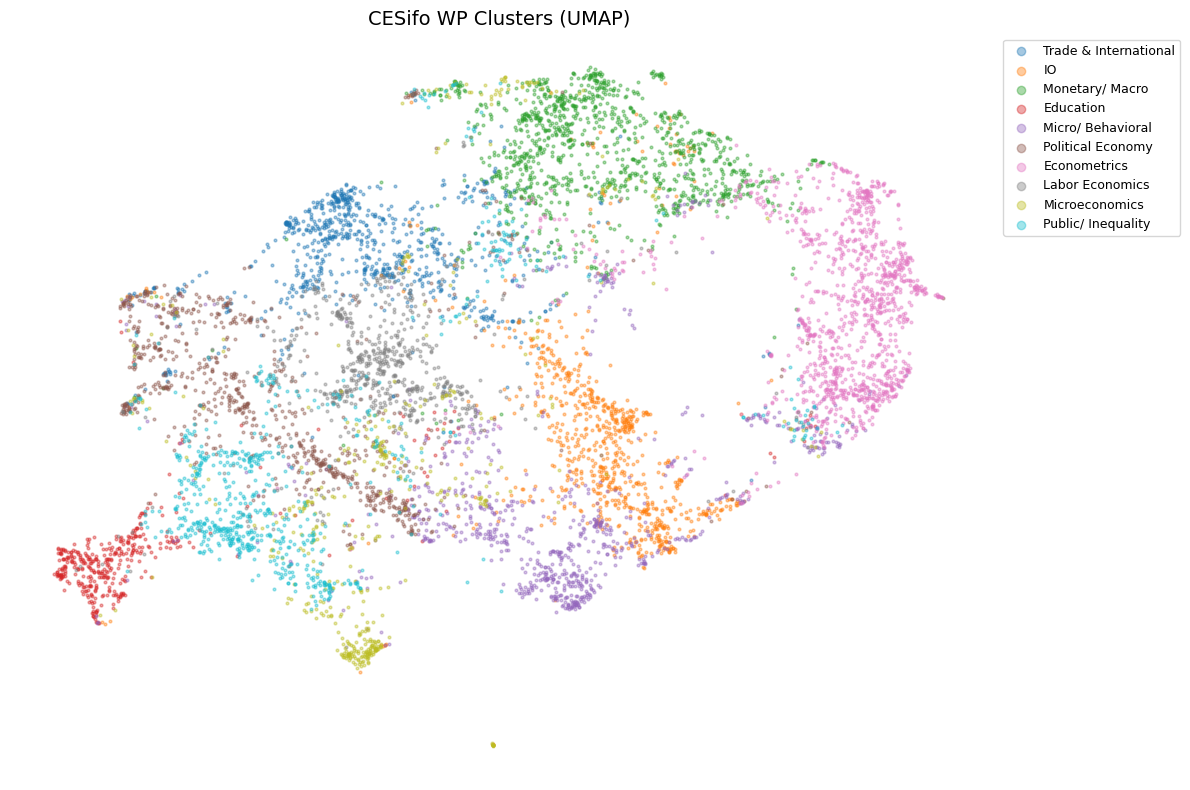

In [ ]:
# Optional: UMAP plot to visualise the clusters (install umap-learn)
try:
    import umap
    print("Running UMAP (this takes a minute)...")
    reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE)
    coords = reducer.fit_transform(paper_embeddings)

    fig, ax = plt.subplots(figsize=(12, 8))
    palette = sns.color_palette('tab10', N_CLUSTERS)
    for cid, label in CLUSTER_LABELS.items():
        mask = dt_paper_level['cluster_id'] == cid
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   s=4, alpha=0.4, color=palette[cid], label=label)
    ax.legend(markerscale=3, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.set_title('Paper Field Clusters (UMAP)', fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('cluster_umap.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print("umap-learn not installed — skipping visualisation. Run: pip install umap-learn")

In [35]:
# print final dataframe with assigned labels	
print("\nFinal dataframe with assigned labels:")
print(dt_paper_level[['paper_id', 'title_paper', 'field_label']].head(15))


Final dataframe with assigned labels:
     paper_id                                        title_paper  \
0           1  'Acting Wife': Marriage Market Incentives and ...   
19          2  'Getting to Denmark': the role of agricultural...   
20          3  'Ghost citizens': Using notches to identify ma...   
24          4                       (Almost) Model-Free Recovery   
43          5             (Il)legal Assignments in School Choice   
46          6  (Mis)Allocation, Market Power, and Global Oil ...   
53          7  (Near-)Substitute Preferences and Equilibria w...   
58          8  (Not) Everyone can be a winner - The role of p...   
68          9  (Not) delegating decisions to experts: The eff...   
69         10  (Re)scheduling pollution exposure: The case of...   
80         11                    (S)CARS AND THE GREAT RECESSION   
81         12   (Successful) Democracies Breed Their Own Support   
84         13  (Trade) War and peace: How to impose internati...   
100      

In [38]:
# save final dataframe to CSV

# Save there
dt_paper_level.to_csv(r'data/gen/papers_fields_classification.csv', index=False)
print("Saved final classification.")

Saved final classification.
